# Manual Test Notebook for LLMJudgeTempCausal

Step-by-step walkthrough of the main pipeline components.

Sections:
1. Setup & Config
2. Data Loading
3. Prompt Building
4. LLM Client & Judge
5. Metrics Computation
6. Causal Analysis
7. Visualization
8. Full ExperimentRunner (quick test)

## 1. Setup & Config

In [1]:
import logging
import sys
import os

# Ensure the project root is on the path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, os.path.join(project_root, "src"))

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
)

print("Project root:", project_root)

Project root: /home/snt/projects_lujun


In [2]:
from llmjudgetempcausal.config import (
    BackendType,
    ExperimentConfig,
    JudgeType,
    ModelConfig,
    PromptVariant,
)

# Adjust model_name, base_url, backend as needed for your setup
model_cfg = ModelConfig(
    model_name="google/gemma-3-1b-it",
    base_url="http://localhost:8000",
    backend=BackendType.VLLM,
    model_size_label="1B",
)

config = ExperimentConfig(
    temperatures=[0.0, 0.5, 1.0],
    judge_types=[JudgeType.PAIRWISE, JudgeType.SINGLE_ANSWER],
    prompt_variants=[PromptVariant.BASELINE, PromptVariant.COT],
    num_repeats=1,
    sample_size=3,
    output_dir="../results_test_notebook",
    models=[model_cfg],
)

print("Config:", config)

Config: ExperimentConfig(temperatures=[0.0, 0.5, 1.0], top_p=0.95, max_tokens=1024, judge_types=[<JudgeType.PAIRWISE: 'pairwise'>, <JudgeType.SINGLE_ANSWER: 'single_answer'>], prompt_variants=[<PromptVariant.BASELINE: 'baseline'>, <PromptVariant.COT: 'cot'>], num_repeats=1, sample_size=3, random_seed=42, output_dir='../results_test_notebook', models=[ModelConfig(model_name='google/gemma-3-1b-it', base_url='http://localhost:8000', api_key='EMPTY', backend=<BackendType.VLLM: 'vllm'>, model_size_label='1B')])


## 2. Data Loading

Load MT-Bench human judgments and sample a small subset.

In [3]:
from llmjudgetempcausal.data import load_mt_bench_human, sample_pairs

all_pairs = load_mt_bench_human()
print(f"Total pairs loaded: {len(all_pairs)}")

pairs = sample_pairs(all_pairs, n=5, seed=42)
print(f"Sampled pairs: {len(pairs)}")

/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-11 14:22:34,367 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/datasets/lmsys/mt_bench_human_judgments/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-03-11 14:22:34,379 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/lmsys/mt_bench_human_judgments/f7d2896d2cc5d80f8b55c2bbc722613555233c25/README.md "HTTP/1.1 200 OK"
2026-03-11 14:22:34,505 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/datasets/lmsys/mt_bench_human_judgments/resolve/f7d2896d2cc5d80f8b55c2bbc722613555233c25/mt_bench_human_judgments.py "HTTP/1.1 404 Not Found"
2026-03-11 14:22:34,806 [INFO] httpx: HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/data

Total pairs loaded: 3355
Sampled pairs: 5


In [4]:
# Inspect first pair
pair = pairs[0]
print(f"Question ID: {pair.question_id}")
print(f"Model A: {pair.model_a}")
print(f"Model B: {pair.model_b}")
print(f"Human winner: {pair.human_winner}")
print(f"Turn: {pair.turn}")
print(f"\nQuestion text:\n{pair.question_text[:300]}")
print(f"\nResponse A (first 300 chars):\n{pair.response_a[:300]}")
print(f"\nResponse B (first 300 chars):\n{pair.response_b[:300]}")

Question ID: 144
Model A: gpt-3.5-turbo
Model B: alpaca-13b
Human winner: tie
Turn: 2

Question text:
What is the central dogma of molecular biology? What processes are involved? Who named this?

Response A (first 300 chars):
I apologize for the mistake in my previous response. The term "central dogma" was actually coined by Francis Crick in 1956, not 1958. Thank you for bringing this to my attention.

Response B (first 300 chars):
The central dogma of molecular biology is the process by which genetic information is transferred from DNA to RNA and then to proteins. This process is mediated by a series of enzymes, including DNA polymerase, RNA polymerase and ribosomes. The central dogma was named by Francis Crick in 1958. 

Cor


## 3. Prompt Building

Build judge prompts for different judge types and prompt variants.

In [5]:
from llmjudgetempcausal.prompts import build_messages

# Pairwise baseline
msgs_pairwise = build_messages(pair, JudgeType.PAIRWISE, PromptVariant.BASELINE)
print("=== Pairwise Baseline ===")
for m in msgs_pairwise:
    print(f"[{m['role']}] {m['content'][:200]}...")
    print()

=== Pairwise Baseline ===
[system] You are a fair and impartial judge. Your task is to evaluate two AI assistant responses to a user question and decide which one is better. You must output exactly one of: [[A]], [[B]], or [[C]] (for t...

[user] [User Question]
What is the central dogma of molecular biology? What processes are involved? Who named this?

[The Start of Assistant A's Answer]
I apologize for the mistake in my previous response. T...



In [6]:
# Pairwise CoT
msgs_cot = build_messages(pair, JudgeType.PAIRWISE, PromptVariant.COT)
print("=== Pairwise CoT ===")
for m in msgs_cot:
    print(f"[{m['role']}] {m['content'][:200]}...")
    print()

=== Pairwise CoT ===
[system] You are a fair and impartial judge. Your task is to evaluate two AI assistant responses to a user question. First, compare them on helpfulness, relevance, accuracy, depth, and creativity. Then compare...

[user] [User Question]
What is the central dogma of molecular biology? What processes are involved? Who named this?

[The Start of Assistant A's Answer]
I apologize for the mistake in my previous response. T...



In [7]:
# Single answer baseline
msgs_single = build_messages(pair, JudgeType.SINGLE_ANSWER, PromptVariant.BASELINE, which_response="a")
print("=== Single Answer (response A) ===")
for m in msgs_single:
    print(f"[{m['role']}] {m['content'][:200]}...")
    print()

=== Single Answer (response A) ===
[system] You are a fair and impartial judge. Rate the quality of the AI assistant's response to the user question on a scale of 1 to 10. Output ONLY a single integer between 1 and 10, enclosed in double bracke...

[user] [User Question]
What is the central dogma of molecular biology? What processes are involved? Who named this?

[The Start of Assistant's Answer]
I apologize for the mistake in my previous response. The...



In [8]:
# Pairwise with position swap
msgs_swap = build_messages(pair, JudgeType.PAIRWISE, PromptVariant.POSITION_SWAP, swapped=True)
print("=== Pairwise Swapped ===")
for m in msgs_swap:
    print(f"[{m['role']}] {m['content'][:200]}...")
    print()

=== Pairwise Swapped ===
[system] You are a fair and impartial judge. Your task is to evaluate two AI assistant responses to a user question and decide which one is better. You must output exactly one of: [[A]], [[B]], or [[C]] (for t...

[user] [User Question]
What is the central dogma of molecular biology? What processes are involved? Who named this?

[The Start of Assistant A's Answer]
The central dogma of molecular biology is the process ...



## 4. LLM Client & Judge

**Requires a running LLM server** (e.g. vLLM on `http://localhost:8000`).

Skip these cells if no server is available.

In [9]:
from llmjudgetempcausal.client import LLMClient

client = LLMClient(model_cfg)
print(f"Client model: {client.model_name}")
print(f"Base URL: {client._get_base_url()}")

Client model: google/gemma-3-1b-it
Base URL: http://localhost:8000/v1


In [18]:
# Test a single generation
raw_output = client.generate(
    msgs_pairwise,
    temperature=2.0,
    top_p=0.95,
    max_tokens=1024,
)
print("Raw output:")
print(raw_output)

2026-03-11 14:30:25,559 [INFO] httpx: HTTP Request: POST http://localhost:8000/v1/completions "HTTP/1.1 200 OK"


Raw output:
[[C]]



In [19]:
from llmjudgetempcausal.judge import parse_pairwise, parse_score

# Parse the pairwise output
winner = parse_pairwise(raw_output)
print(f"Parsed winner: {winner}")

Parsed winner: C


In [20]:
from llmjudgetempcausal.judge import run_judge_single, run_judge_pair_consistency

# Run full judge on one pair (pairwise)
results = run_judge_single(
    client=client,
    pair=pair,
    judge_type=JudgeType.PAIRWISE,
    prompt_variant=PromptVariant.BASELINE,
    temperature=0.0,
    top_p=0.95,
    max_tokens=1024,
    repeat_id=0,
    model_size_label="1B",
)

for r in results:
    print(f"Q{r.question_id} | winner={r.pairwise_winner} | human={r.human_winner} | error={r.parse_error}")
    print(f"  raw: {r.raw_output[:200]}")

2026-03-11 14:30:26,903 [INFO] httpx: HTTP Request: POST http://localhost:8000/v1/completions "HTTP/1.1 200 OK"


Q144 | winner=C | human=tie | error=False
  raw: [[C]]


In [21]:
# Run consistency check (original + swapped)
r_orig, r_swap = run_judge_pair_consistency(
    client=client,
    pair=pair,
    prompt_variant=PromptVariant.BASELINE,
    temperature=0.0,
    top_p=0.95,
    max_tokens=1024,
    repeat_id=0,
    model_size_label="1B",
)

print(f"Original: winner={r_orig.pairwise_winner}")
print(f"Swapped:  winner={r_swap.pairwise_winner} (flipped back)")
print(f"Consistent: {r_orig.pairwise_winner == r_swap.pairwise_winner}")

2026-03-11 14:30:30,287 [INFO] httpx: HTTP Request: POST http://localhost:8000/v1/completions "HTTP/1.1 200 OK"
2026-03-11 14:30:30,332 [INFO] httpx: HTTP Request: POST http://localhost:8000/v1/completions "HTTP/1.1 200 OK"


Original: winner=C
Swapped:  winner=B (flipped back)
Consistent: False


## 5. Metrics Computation

Compute metrics on existing results or mock data.

In [22]:
import pandas as pd
from pathlib import Path

# Try loading existing results, or use mock data
results_path = Path(project_root) / "results_test" / "results.csv"

if results_path.exists():
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} results from {results_path}")
    print(f"Columns: {list(df.columns)}")
    df.head()

In [23]:
from llmjudgetempcausal.metrics import (
    compute_agreement_s1,
    compute_agreement_s2,
    compute_consistency,
    compute_error_rate,
    compute_position_bias,
    compute_score_stats,
    compute_all_metrics,
    aggregate_metrics_by_group,
)

if results_path.exists():
    pw = df[df["judge_type"] == "pairwise"]
    print(f"Pairwise samples: {len(pw)}")
    print(f"Agreement S1: {compute_agreement_s1(pw):.4f}")
    print(f"Agreement S2: {compute_agreement_s2(pw):.4f}")
    print(f"Error rate:   {compute_error_rate(pw):.4f}")
    print(f"Position bias: {compute_position_bias(pw)}")
else:
    print("No results file found. Run the experiment first or use section 8.")

No results file found. Run the experiment first or use section 8.


In [24]:
# Aggregate metrics by temperature
if results_path.exists():
    agg = aggregate_metrics_by_group(df, ["temperature"])
    display(agg)

In [25]:
# Aggregate metrics by temperature × judge_type
if results_path.exists():
    agg2 = aggregate_metrics_by_group(df, ["temperature", "judge_type"])
    display(agg2)

In [26]:
# Full metrics
if results_path.exists():
    all_metrics = compute_all_metrics(df)
    for k, v in sorted(all_metrics.items()):
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

## 6. Causal Analysis

Build the DAG and run ATE estimation.

In [27]:
from llmjudgetempcausal.causal import (
    build_causal_dag,
    visualize_dag,
    prepare_dml_data,
    estimate_ate_simple,
    estimate_ate_dml,
    stratified_analysis,
)

# Build and visualize the DAG
dag = build_causal_dag()
print("DAG nodes:", list(dag.nodes()))
print("DAG edges:", list(dag.edges()))

DAG nodes: ['Temperature', 'Judgment', 'JudgeModelSize', 'PromptType', 'InputResponses', 'Metrics', 'HumanJudgment']
DAG edges: [('Temperature', 'Judgment'), ('Temperature', 'Metrics'), ('Judgment', 'Metrics'), ('JudgeModelSize', 'Judgment'), ('JudgeModelSize', 'Metrics'), ('PromptType', 'Judgment'), ('PromptType', 'Metrics'), ('InputResponses', 'Judgment'), ('HumanJudgment', 'Metrics')]


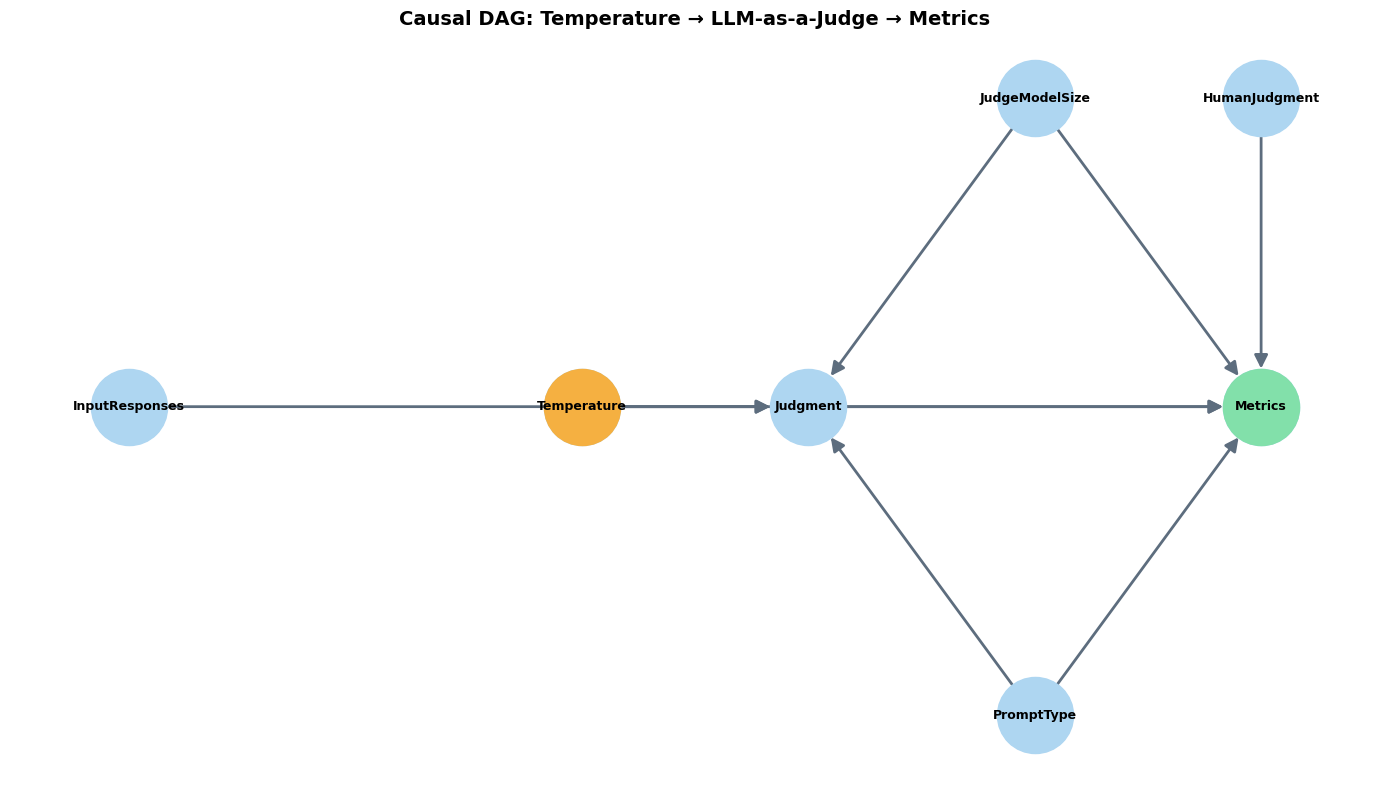

In [28]:
# Visualize and display in notebook
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph(dag.edges())
pos = {
    "Temperature": (0, 2),
    "JudgeModelSize": (2, 3),
    "PromptType": (2, 1),
    "InputResponses": (-2, 2),
    "Judgment": (1, 2),
    "HumanJudgment": (3, 3),
    "Metrics": (3, 2),
}

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
nx.draw(G, pos, ax=ax, with_labels=True, node_color="#AED6F1",
        node_size=3000, font_size=9, font_weight="bold",
        arrowsize=20, edge_color="#5D6D7E", width=2)
nx.draw_networkx_nodes(G, pos, nodelist=["Temperature"], node_color="#F5B041", node_size=3000, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=["Metrics"], node_color="#82E0AA", node_size=3000, ax=ax)
ax.set_title("Causal DAG: Temperature → LLM-as-a-Judge → Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [29]:
# DML causal analysis on existing results
if results_path.exists():
    dml_df = prepare_dml_data(df)
    print(f"DML data shape: {dml_df.shape}")
    if len(dml_df) > 0:
        display(dml_df.head())

        simple_ate = estimate_ate_simple(dml_df, outcome_col="agreement")
        print(f"\nSimple ATE: {simple_ate}")

        dml_ate = estimate_ate_dml(dml_df)
        print(f"DML ATE: {dml_ate}")
else:
    print("No results file. Run the experiment first.")

No results file. Run the experiment first.


In [30]:
# Stratified analysis
if results_path.exists() and len(dml_df) > 0:
    strat = stratified_analysis(dml_df, "prompt_variant", "agreement")
    for k, v in strat.items():
        print(f"  {k}: {v}")

## 7. Visualization

Generate plots from existing results.

In [31]:
from llmjudgetempcausal.visualize import (
    plot_metrics_by_temperature,
    plot_heatmap_temp_prompt,
    plot_heatmap_temp_model,
)

results_dir = Path(project_root) / "results_test"

if (results_dir / "metrics_by_temperature.csv").exists():
    plot_metrics_by_temperature(results_dir)
    print("Generated: plot_metrics_by_temperature.png")
else:
    print("No metrics_by_temperature.csv found.")

if (results_dir / "metrics_by_temp_prompt.csv").exists():
    plot_heatmap_temp_prompt(results_dir)
    print("Generated: heatmaps")

if (results_dir / "metrics_by_temp_model.csv").exists():
    plot_heatmap_temp_model(results_dir)
    print("Generated: model heatmaps")

No metrics_by_temperature.csv found.


In [32]:
# Display generated plots inline
from IPython.display import Image, display as ipy_display

plot_file = results_dir / "plot_metrics_by_temperature.png"
if plot_file.exists():
    ipy_display(Image(filename=str(plot_file)))
else:
    print("No plot file found. Run visualization cell above first.")

No plot file found. Run visualization cell above first.


## 8. Full ExperimentRunner (Quick Test)

**Requires a running LLM server.** Runs the full pipeline with minimal settings.

In [35]:
from llmjudgetempcausal.experiment import ExperimentRunner

# Minimal config for quick testing
quick_config = ExperimentConfig(
    temperatures=[0.0, 1.0],
    judge_types=[JudgeType.PAIRWISE],
    prompt_variants=[PromptVariant.BASELINE],
    num_repeats=1,
    sample_size=2,
    output_dir="../results_test_notebook",
    models=[
        ModelConfig(
            model_name="google/gemma-3-1b-it",
            base_url="http://localhost:8000",
            backend=BackendType.VLLM,
            model_size_label="1B",
        ),
    ],
)

print("Quick config:")
print(f"  Temperatures: {quick_config.temperatures}")
print(f"  Judge types: {quick_config.judge_types}")
print(f"  Prompt variants: {quick_config.prompt_variants}")
print(f"  Repeats: {quick_config.num_repeats}")
print(f"  Sample size: {quick_config.sample_size}")

Quick config:
  Temperatures: [0.0, 1.0]
  Judge types: [<JudgeType.PAIRWISE: 'pairwise'>]
  Prompt variants: [<PromptVariant.BASELINE: 'baseline'>]
  Repeats: 1
  Sample size: 2


In [36]:
# Run the full pipeline
runner = ExperimentRunner(quick_config)
runner.run_all()

2026-03-11 14:33:11,337 [INFO] llmjudgetempcausal.experiment: Loading MT-Bench human judgments...
2026-03-11 14:33:11,510 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/datasets/lmsys/mt_bench_human_judgments/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-03-11 14:33:11,522 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/lmsys/mt_bench_human_judgments/f7d2896d2cc5d80f8b55c2bbc722613555233c25/README.md "HTTP/1.1 200 OK"
2026-03-11 14:33:11,642 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/datasets/lmsys/mt_bench_human_judgments/resolve/f7d2896d2cc5d80f8b55c2bbc722613555233c25/mt_bench_human_judgments.py "HTTP/1.1 404 Not Found"
2026-03-11 14:33:13,581 [INFO] httpx: HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/lmsys/mt_bench_human_judgments/lmsys/mt_bench_human_judgments.py "HTTP/1.1 404 Not Found"
2026-03-11 14:33:13,739 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/da

In [37]:
# Inspect results
results_nb_dir = Path("../results_test_notebook")
if (results_nb_dir / "results.csv").exists():
    df_nb = pd.read_csv(results_nb_dir / "results.csv")
    print(f"Total results: {len(df_nb)}")
    display(df_nb.head(10))

if (results_nb_dir / "analysis.json").exists():
    import json
    with open(results_nb_dir / "analysis.json") as f:
        analysis = json.load(f)
    print("\nAnalysis:")
    print(json.dumps(analysis, indent=2))

Total results: 4


,question_id,model_a,model_b,human_winner,judge_type,prompt_variant,temperature,model_name,model_size_label,repeat_id,raw_output,pairwise_winner,score_a,score_b,is_swapped,parse_error
0,144,gpt-3.5-turbo,alpaca-13b,tie,pairwise,baseline,0.0,google/gemma-3-1b-it,1B,0,[[A]],A,NaN,NaN,False,False
1,92,gpt-3.5-turbo,claude-v1,model_b,pairwise,baseline,0.0,google/gemma-3-1b-it,1B,0,[[B]],B,NaN,NaN,False,False
2,144,gpt-3.5-turbo,alpaca-13b,tie,pairwise,baseline,1.0,google/gemma-3-1b-it,1B,0,[[A]],A,NaN,NaN,False,False
3,92,gpt-3.5-turbo,claude-v1,model_b,pairwise,baseline,1.0,google/gemma-3-1b-it,1B,0,[[B]],B,NaN,NaN,False,False



Analysis:
{
  "by_temperature": [
    {
      "temperature": 0.0,
      "agreement_s1": 1.0,
      "agreement_s2": 1.0,
      "error_rate_pairwise": 0.0,
      "position_p_first": 0.5,
      "position_p_second": 0.5,
      "position_bias": 0.0,
      "position_abs_bias": 0.0,
      "n_samples": 2
    },
    {
      "temperature": 1.0,
      "agreement_s1": 1.0,
      "agreement_s2": 1.0,
      "error_rate_pairwise": 0.0,
      "position_p_first": 0.5,
      "position_p_second": 0.5,
      "position_bias": 0.0,
      "position_abs_bias": 0.0,
      "n_samples": 2
    }
  ],
  "simple_ate": {
    "ate_simple": 0.0,
    "means_by_temp": {
      "0.0": 0.5,
      "1.0": 0.5
    },
    "stds_by_temp": {
      "0.0": 0.7071067811865476,
      "1.0": 0.7071067811865476
    },
    "counts_by_temp": {
      "0.0": 2,
      "1.0": 2
    },
    "anova_f": 0.0,
    "anova_p": 1.0,
    "spearman_rho": NaN,
    "spearman_p": NaN
  },
  "dml_ate": {
    "error": "insufficient_data",
    "n": 4
  },


## 9. Parser Unit Tests

Quick sanity checks on the output parsers (no server needed).

In [38]:
from llmjudgetempcausal.judge import parse_pairwise, parse_score

# Pairwise parser tests
test_cases_pw = [
    ("The winner is [[A]]", "A"),
    ("I think [[B]] is better", "B"),
    ("It's a [[C]] tie", "C"),
    ("Assistant A is better overall", "A"),
    ("Assistant B is better", "B"),
    ("This is a tie", "C"),
    ("No clear verdict here...", None),
]

print("Pairwise parser tests:")
for text, expected in test_cases_pw:
    result = parse_pairwise(text)
    status = "PASS" if result == expected else "FAIL"
    print(f"  [{status}] parse_pairwise({text!r:.50}) -> {result} (expected {expected})")

# Score parser tests
test_cases_score = [
    ("Rating: [[7]]", 7.0),
    ("I give it a [[9.5]]", 9.5),
    ("Score: 8 out of 10", 8.0),
    ("No score here", None),
    ("[[15]]", None),  # out of range
]

print("\nScore parser tests:")
for text, expected in test_cases_score:
    result = parse_score(text)
    status = "PASS" if result == expected else "FAIL"
    print(f"  [{status}] parse_score({text!r:.50}) -> {result} (expected {expected})")

Pairwise parser tests:
  [PASS] parse_pairwise('The winner is [[A]]') -> A (expected A)
  [PASS] parse_pairwise('I think [[B]] is better') -> B (expected B)
  [PASS] parse_pairwise("It's a [[C]] tie") -> C (expected C)
  [PASS] parse_pairwise('Assistant A is better overall') -> A (expected A)
  [PASS] parse_pairwise('Assistant B is better') -> B (expected B)
  [PASS] parse_pairwise('This is a tie') -> C (expected C)
  [PASS] parse_pairwise('No clear verdict here...') -> None (expected None)

Score parser tests:
  [PASS] parse_score('Rating: [[7]]') -> 7.0 (expected 7.0)
  [PASS] parse_score('I give it a [[9.5]]') -> 9.5 (expected 9.5)
  [PASS] parse_score('Score: 8 out of 10') -> 8.0 (expected 8.0)
  [PASS] parse_score('No score here') -> None (expected None)
  [PASS] parse_score('[[15]]') -> None (expected None)
